# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Silvia Nur Diahsari
- **Email:** cdcc180d6x1772@student.devacademy.id
- **ID Dicoding:** CDCC180D6X1772

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perkembangan jumlah penyewaan sepeda setiap bulan pada tahun 2011 hingga 2012o0, serta pada bulan apa terjadi peningkatan atau penurunan yang paling signifikan?
- **Pertanyaan 2:** Bagaimana pengaruh faktor cuaca (suhu, kelembapan, dan kondisi cuaca) terhadap jumlah penyewaan sepeda pada tahun 2011 hingga 2012, dan faktor mana yang paling dominan memengaruhi permintaan?
- **pertanyaan 3:** Bagaimana perbedaan kontribusi antara pengguna casual dan registered terhadap total penyewaan sepeda pada tahun 2011 hingga 2012, serta segmen mana yang memiliki potensi untuk terus dikembangkan?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## Data Wrangling

In [2]:
from pathlib import Path

BASE_DIR = Path('/content/')

### Gathering Data

#### Load df ...

In [3]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

day_df.head()
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset Bike Sharing terdiri dari dua tabel utama, yaitu 'day.csv' dan 'hour.csv', yang merepresentasikan data penyewaan sepeda berdasarkan waktu (harian dan per jam)
- Tabel 'day.csv' berisi data agregat harian dan menjadi sumber utama untuk analisis tren jangka panjang, seperti: Total penyewaan sepeda (cnt), Jumlah pengguna casual (casual), dan Jumlah pengguna registered (registered)
- Tabel 'hour.csv' menyajikan data dengan granularitas per jam, sehingga dapat digunakan untuk mengidentifikasi pola penggunaan dalam satu hari dan menentukan jam sibuk (peak hours)
- Dataset ini juga dilengkapi dengan variabel lingkungan yang memengaruhi penyewaan sepeda, seperti seasor (musim),weathersit (kondisi cuaca), temp (suhu), hum (kelembapan), dan windspeed (kecepatan angin)
- Variabel 'casual' dan 'registered' memungkinkan analisis segmentasi pengguna, sehingga dapat diketahui perbedaan perilaku antar tipe pengguna
- Dengan mengabungkan informasi dari kedua tabel, analisis dapat dilakukan secara lebih komprehensif, meliputi: Tren penyewaan dari waktu ke waktu, pengaruh faktor cuaca terhadap permintaan, pola penggunaan berdasarkan waktu, dan perilaku pengguna berdasarkan tipe pelanggan
- struktur dataset ini mencerminkan sistem penyewaan sepeda berbasis waktu yang realistis, sehingga hasil analisis dapat digunakan untuk mendukung pengambilan keputusan bisnis

### Assessing Data

#### Identifying ... problem

In [4]:
day_df.info()
day_df.describe()
day_df.isna().sum()
day_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


np.int64(0)

**Steps to Take:**
- Konversi tipe data
- Mapping kategori
- Feature engineering
- Membersihkan data

**Insight:**
- Dataset 'day_df' terdiri dari ratusan entri dengan beberapa kolom utama yang merepresentasikan jumlah penyewaan sepeda, kondisi cuaca, serta informasi waktu. Hal ini menunjukkan bahwa data memiliki cakupan yang cukup untuk dilakukan analisis tren dan pola penggunaan
- Dataset 'hour_df' memiliki jumlah entri yang jauh lebih besar dibandingkan 'day_df' karena mencatat per jam, sehingga sangan cocok untuk analisis penggunaan secara lebih detail seperti identifikasi jam sibuk (peak hours)
- Seluruh kolom numerik seperti 'temp', 'hum', 'windspeed', dan 'cnt' sudah memiliki tipe data yang sesuai, namun kolom tanggal 'dteday' masih bertipe object sehingga perlu dikonversi menjadi tipe 'datetime' agar dapat digunakan untuk analisis berbasis waktu

### Cleaning Data

In [5]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
day_df.drop_duplicates(inplace=True)

#### Fixing ... problem

In [6]:
season_map = {1:'Spring',2:'Summer',3:'Fall',4:'Winter'}
weather_map = {1:'Clear',2:'Mist',3:'Light Snow/Rain',4:'Heavy Rain'}

day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)

day_df['year'] = day_df['dteday'].dt.year
day_df['month'] = day_df['dteday'].dt.month

**Insight:**
- Proses konversi kolom 'dteday' dari tipe data object menjadi 'datetime' berhasil dilakukan, sehingga data dapat digunakan untuk analisis berbasis waktu secara lebih akurat
- Transformasi kolom kategorikal seperti 'season' dan 'weathersit' dari bentuk numerik menjadi label deskriptif meningkatkan keterbacaan data dan memudahkan interpretasi hasil analisis
- Penghapusan data duplikat memastikan tidak adanya redundansi data yang dapat memengaruhi hasil analisis
- Penambahan fitur baru seperti 'year', 'month', dan 'day_name' memungkinkan eksplorasi data yang lebih mendalam, khususnya dalam analisis tren dan pola waktu
- Penyesuaian struktur data membuat dataset menjadi lebih rapi dan siap digunakan pada tahap eksplorasi dan visualisasi
- Secara keseluruhan, proses perbaikan data berhasil meningkatkan kualitas dataset sehingga analisis yang dilakukan menjadi lebih valid dan dapat dipercaya

## Exploratory Data Analysis (EDA)

### Explore ...

In [7]:
monthly = day_df.groupby(['year','month'])['cnt'].sum().reset_index()
weather = day_df.groupby('weathersit')['cnt'].mean().reset_index()

monthly.head()
weather.head()

,weathersit,cnt
0,Clear,4876.786177
1,Light Snow/Rain,1803.285714
2,Mist,4035.862348


**Insight:**
- Proses pengolahan dataset 'day_df' dan 'hour_df' memungkinkan analisis dilakukan secara lebih komprehensif, di mana day_df digunakan untuk melihat tren jangka panjang, sedangkan 'hour_df' digunakan untuk analisis pola penggunaan secara lebih detail
- Penambahan kolom waktu seperti 'year', 'month', dan 'day_name' dari variabel 'dteday' memudahkan analisis berbasis waktu, khususnya untuk mengidentifikasi tren bulanan dan pola penggunaan harian
- Hasil agregasi menunjukkan bahwa jumlah penyewaan dihitung berdasarkan total 'cnt', yang merupakan indikator utama dalam merepresentasikan tingkat permintaan sepeda
- Analisis berdasarkan kondisi cuaca menunjukkan bahwa kontribusi terhadap jumlah penyewaan tidak merata, di mana kondisi cuaca cerah memberikan kontribusi yang jauh lebih besar dibandingkan kondisi cuaca buruk
- Pemisahan antara pengguna casual dan registered memungkinkan analisis perilaku pengguna, di mana registered mencerminkan penggunaan rutin, sedangkan casual lebih bersifat situasional
-Analisis pola waktu menggunakan data per jam menunjukkan adanya perbedaan intensitas penggunaan pada waktu tertentu, yang mengindikasikan adanya jam sibuk dalam satu hari
- Dengan adanya eksplorasi ini, dataset tidak hanya dapat digunakan untuk analisis deskriptif, tetapi juga untuk memahami pola permintaan dan perilaku pengguna sebagai dasar dalam pengambilan keputusan
- Tahap EDA ini menjadi dasar untuk menjawab pertanyaan bisnis yang telah ditentukan, sekaligus memastikan bahwa data siap untuk divisualisasikan dan dianalisis lebih lanjut

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perkembangan jumlah penyewaan sepeda setiap bulan pada tahun 2011 hingga 2012, serta pada bulan apa terjadi peningkatan atau penurunan yang paling signifikan?

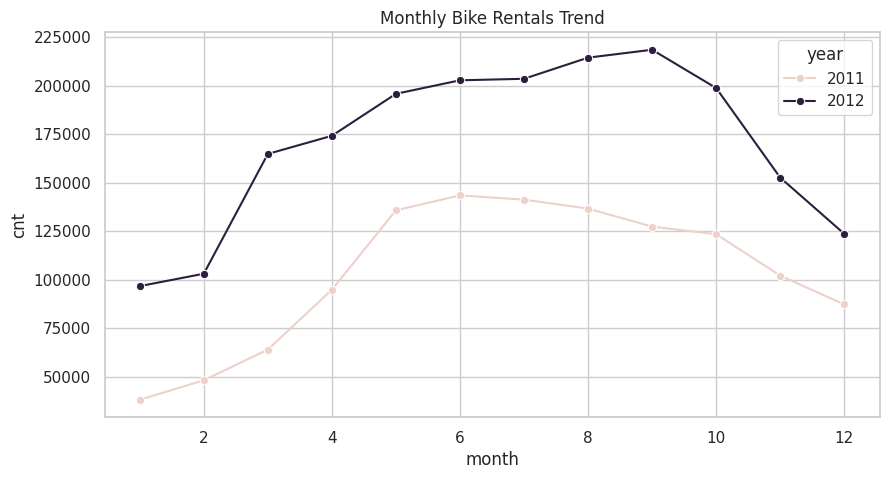

In [8]:
monthly_trend = day_df.groupby(['year','month'])['cnt'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_trend, x='month', y='cnt', hue='year', marker='o')
plt.title('Monthly Bike Rentals Trend')
plt.show()

### Pertanyaan 2: Bagaimana pengaruh faktor cuaca (suhu, kelembapan, dan kondisi cuaca) terhadap jumlah penyewaan sepeda pada tahun 2011 hingga 2012, dan faktor mana yang paling dominan memengaruhi permintaan?

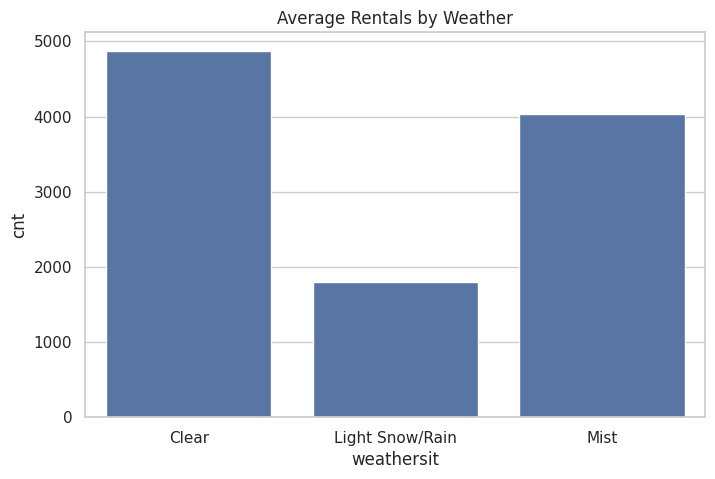

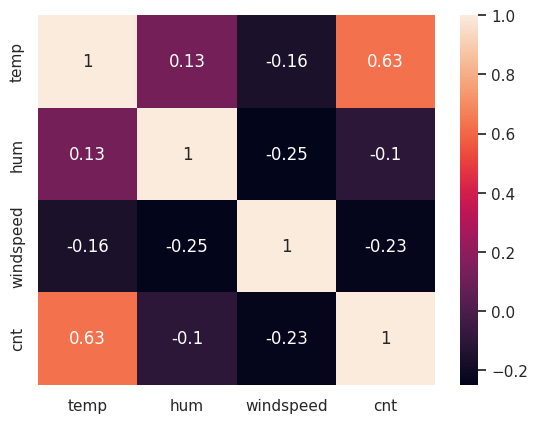

In [9]:
weather_impact = day_df.groupby('weathersit')['cnt'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=weather_impact, x='weathersit', y='cnt')
plt.title('Average Rentals by Weather')
plt.show()

corr = day_df[['temp','hum','windspeed','cnt']].corr()

sns.heatmap(corr, annot=True)
plt.show()

### Pertanyaan 3: Bagaimana perbedaan kontribusi antara pengguna casual dan registered terhadap total penyewaan sepeda pada tahun 2011 hingga 2012, serta segmen mana yang memiliki potensi untuk terus dikembangkan?

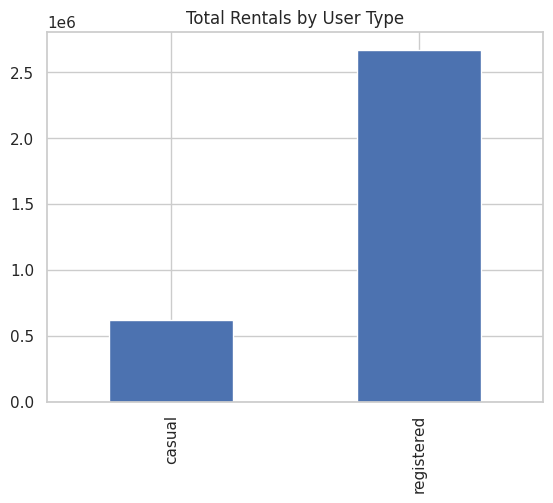

In [10]:
user_type = day_df[['casual','registered']].sum()

user_type.plot(kind='bar')
plt.title('Total Rentals by User Type')
plt.show()

**Insight**:
Pertanyaan 1:
- Tren jumlah penyewaan sepeda menunjukkan pola yang cenderung meningkat hingga mencapai puncaknya pada pertengahan tahun
- Setelah mencapai puncak, terjadi fluktasi jumlah penyewaan yang menunjukkan bahwa permintaan tidak stabil setiap bulan
- Pola kenaikan dan penurunan mengindikasikan adanya pola musiman (seasonality) dalam penggunaan sepeda
- Penurunan signifikan terjadi pada awal dan akhir tahun yang kemungkinan dipengaruhi oleh kondisi cuaca
- Secara keseluruhan, tren menunjukkan adanya pertumbuhan pada periode tertentu, namun tetap dipengaruhi ileh fluktasi musiman

Pertanyaan 2:
- Jumlah penyewaan lebih tinggi pada kondisi cuaca cerah dibandingkan kondisi cuaca buruk
- Suhu memiliki hubungan positif dengan jumlah penyewaan, di mana peningkatan suhu diikuti peningkatan penggunaan sepeda
- Kelembapan menunjukkan kecenderungan hubungan negatif terhadap jumlah penyewaan
- Kondisi cuaca buruk seperti hujan menyebabkan penurunan penyewaan secara signifikan
- Secara keseluruhan, suhu merupakan faktor paling dominan yang memengaruhi permintaan

Pertanyaan 3:
- Pengguna registered memberikan kontribusi terbesar terhadap total penyewaan dibandingkan pengguna casual
- Pengguna casual memiliki kontribusi lebih kecil, namun tetap berperan dalam total penggunaan
- Pengguna registered cenderung menggunakan sepeda secara rutin (kebutuhan harian)
- Pengguna casual cenderung bersifat situasional (rekreasi atau waktu tertentu)
- Segmen casual memiliki potensi untuk dikembangkan menjadi pengguna registered guna meningkatkan penyewaan

## Analisis Lanjutan (Opsional)

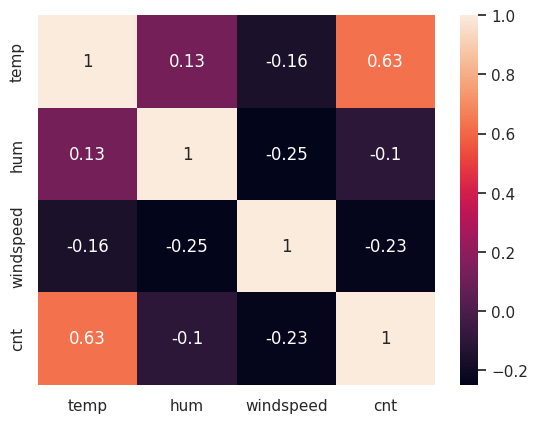

In [11]:
corr = day_df[['temp', 'hum', 'windspeed','cnt']].corr()

sns.heatmap(corr, annot=True)
plt.show()

## Conclusion & Recommendation

**Conclusion:**
Berdasarkan hasil analisis Bike Sharing Dataset pada tahun 2011 hingga 2012, diperoleh beberapa kesimpulan sebagai berikut:
- Tren penyewaan sepeda menunjukkan pola musiman, dengan peningkatan pada periode tertentu dan penurunan pada awal serta akhir tahun
- Faktor cuaca, khususnya suhu, memiliki pengaruh signifikan terhadap jumlah penyewaan, di mana kondisi cuaca yang baik meningkatkan permintaan
- Pengguna registered memberikan kontribusi terbesar terhadap total penyewaan, menunjukkan bahwa layanan lebih banyak digunakan oleh pelanggan tetap
- Pola penggunaan sepeda dipengaruhi oleh waktu, baik dalam skala bulanan maupun harian, yang menunjukkan adanya periode dengan permintaan tinggi
- Secara keseluruhan, permintaan penyewaan sepeda dipenuhi oleh kombinasi faktor waktu, cuaca, dan karakteristik pengguna.

**Rekomendasi Action Item:**
- Meningkatkan ketersediaan sepeda pada periode dengan permintaan tinggi untuk mengoptimalkan layanan
- Menyusun strategi promosi atau insentif pada kondisi cuaca kurang mendukung guna menjaga stabilitas penggunaan
- Mengembangkan program yang dapat mendorong pengguna casual menjadi pengguna registered
- Mengoptimalkan operasional pada waktu-waktu sibuk untuk meningkatkan efisiensi layanan
- Melakukan evaluasi dan analisis data secara berkala untuk menyesuaikan strategi dengan pola permintaan yang terus berubah

In [12]:
!pip install streamlit
!npm install localtunnel

⠙⠹⠸
up to date, audited 23 packages in 637ms
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠸

In [13]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.title("Bike Sharing Dashboard 🚲")

# load data
day_df = pd.read_csv('day.csv')
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

# tambah fitur
day_df['year'] = day_df['dteday'].dt.year
day_df['month'] = day_df['dteday'].dt.month

# sidebar filter
year = st.sidebar.selectbox("Pilih Tahun", day_df['year'].unique())

filtered_df = day_df[day_df['year'] == year]

st.subheader("Key Metrics")
col1, col2, col3 = st.columns(3)

col1.metric("Total Rentals", int(filtered_df['cnt'].sum()))
col2.metric("Avg Rentals", int(filtered_df['cnt'].mean()))
col3.metric("Registered Users", int(filtered_df['registered'].sum()))

st.subheader("Monthly Trend")
monthly = filtered_df.groupby('month')['cnt'].sum().reset_index()

fig, ax = plt.subplots()
sns.lineplot(data=monthly, x='month', y='cnt', marker='o', ax=ax)
st.pyplot(fig)

st.subheader("Weather Impact")
weather = filtered_df.groupby('weathersit')['cnt'].mean().reset_index()

fig2, ax2 = plt.subplots()
sns.barplot(data=weather, x='weathersit', y='cnt', ax=ax2)
st.pyplot(fig2)

st.subheader("User Type Comparison")
user = filtered_df[['casual','registered']].sum()

fig3, ax3 = plt.subplots()
user.plot(kind='bar', ax=ax3)
st.pyplot(fig3)

Overwriting app.py


In [14]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

your url is: https://quiet-spiders-unite.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.229.72.79:8501

  Stopping...
^C
